In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [31]:
df= pd.read_csv('loan_approval.csv')
df.head()

,age,income_k,credit_score,approved
0,24,43,773,1
1,55,69,590,0
2,49,29,793,1
3,40,40,593,1
4,40,90,638,0


In [32]:
print("Shape of the DataFrame:")
print(df.shape)
print("Summary of the DataFrame:")
print(df.info())
print("Columns of the DataFrame:")
print(df.columns)
print('decribe the data')
print(df.describe(include='all').T)
print('count the number of null values')
print(df.isnull().sum())
print('count the number of duplicate values')
print(df.duplicated().sum())



Shape of the DataFrame:
(50, 4)
Summary of the DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           50 non-null     int64
 1   income_k      50 non-null     int64
 2   credit_score  50 non-null     int64
 3   approved      50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB
None
Columns of the DataFrame:
Index(['age', 'income_k', 'credit_score', 'approved'], dtype='str')
decribe the data
              count    mean        std    min     25%    50%     75%    max
age            50.0   44.28  12.327239   23.0   36.25   44.5   55.00   63.0
income_k       50.0   68.18  24.844570   26.0   45.50   69.0   89.75  117.0
credit_score   50.0  656.24  87.965104  507.0  593.75  644.5  722.00  818.0
approved       50.0    0.46   0.503457    0.0    0.00    0.0    1.00    1.0
count the number of null values
age             0
income_k        0
cre

In [33]:
df.approved.value_counts()

approved
0    27
1    23
Name: count, dtype: int64

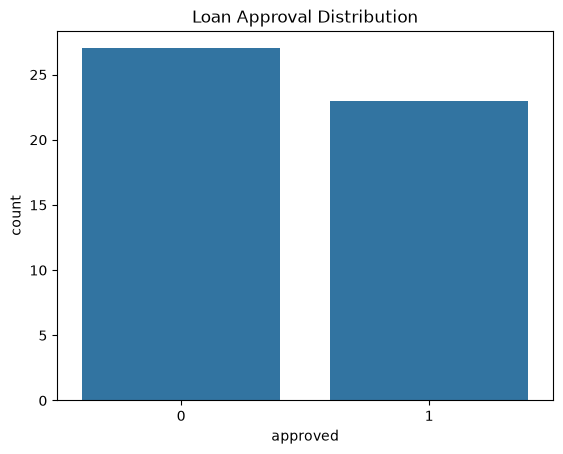

In [34]:
sns.countplot(data=df, x="approved")

plt.title("Loan Approval Distribution")
plt.show()

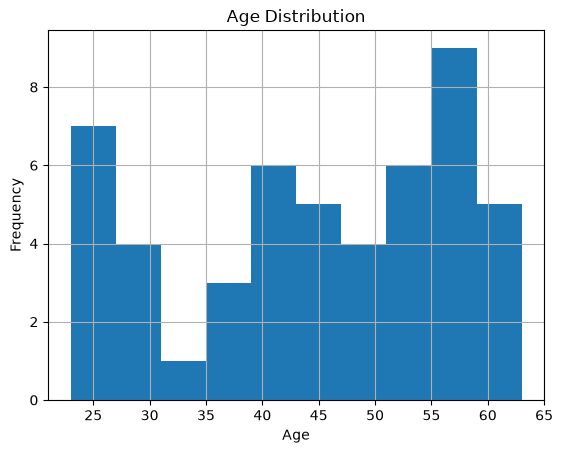

In [35]:
df["age"].hist()

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

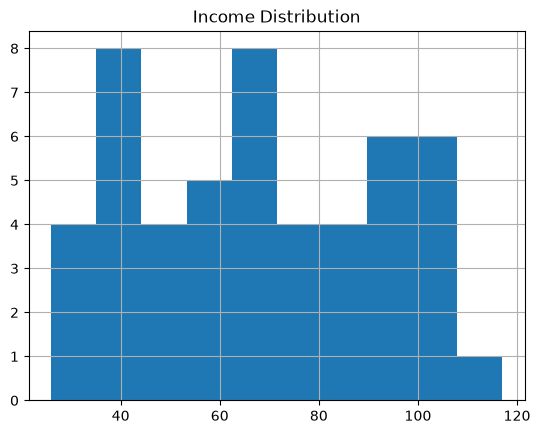

In [36]:
df["income_k"].hist()

plt.title("Income Distribution")
plt.show()

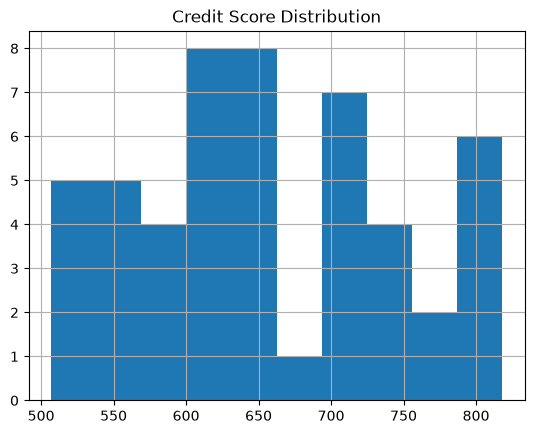

In [37]:
df["credit_score"].hist()

plt.title("Credit Score Distribution")
plt.show()

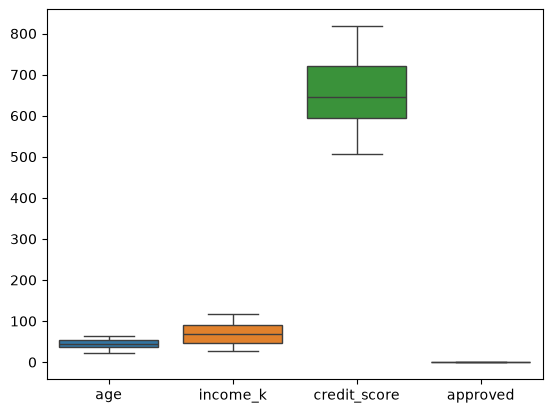

In [38]:
sns.boxplot(data=df)

plt.show()

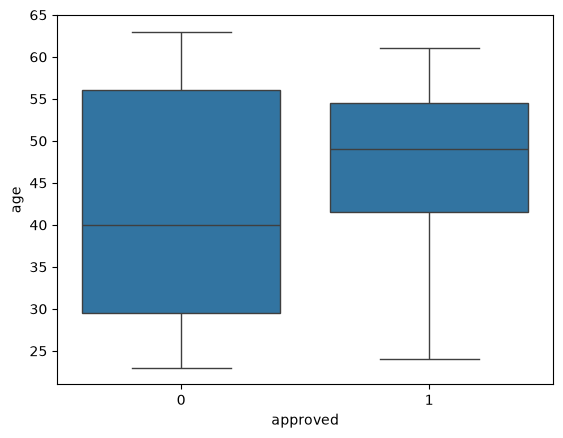

In [39]:
sns.boxplot(
    data=df,
    x="approved",
    y="age"
)

plt.show()

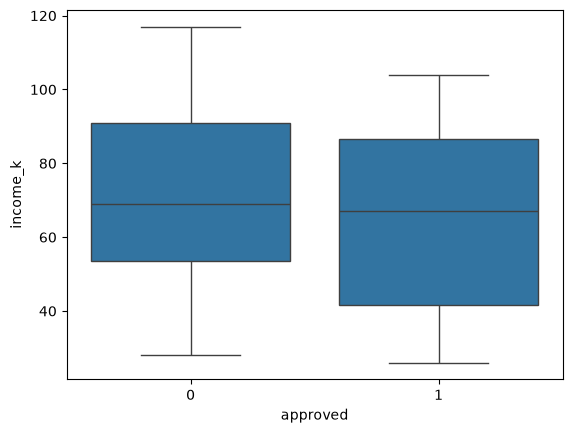

In [40]:
sns.boxplot(
    data=df,
    x="approved",
    y="income_k"
)

plt.show()

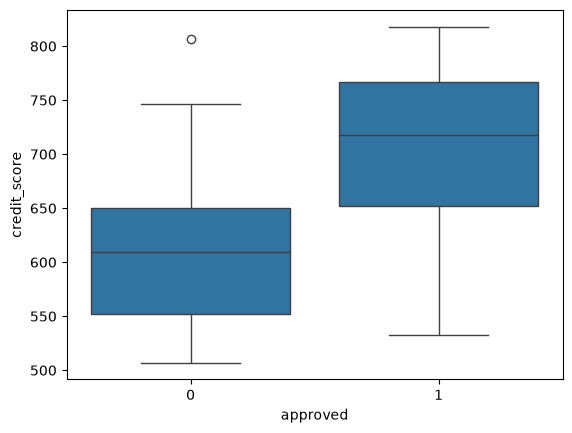

In [41]:
sns.boxplot(
    data=df,
    x="approved",
    y="credit_score"
)

plt.show()

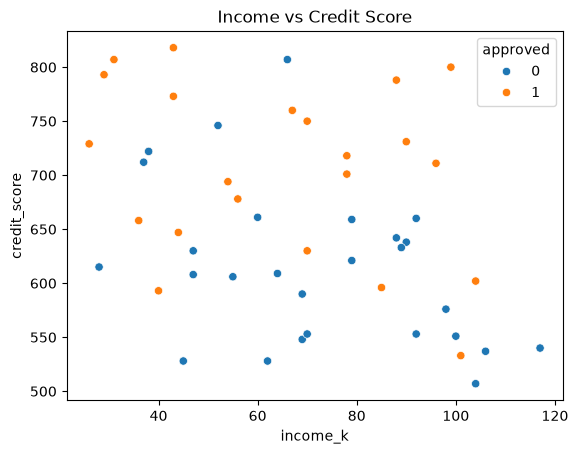

In [42]:
sns.scatterplot(
    data=df,
    x="income_k",
    y="credit_score",
    hue="approved"
)

plt.title("Income vs Credit Score")
plt.show()

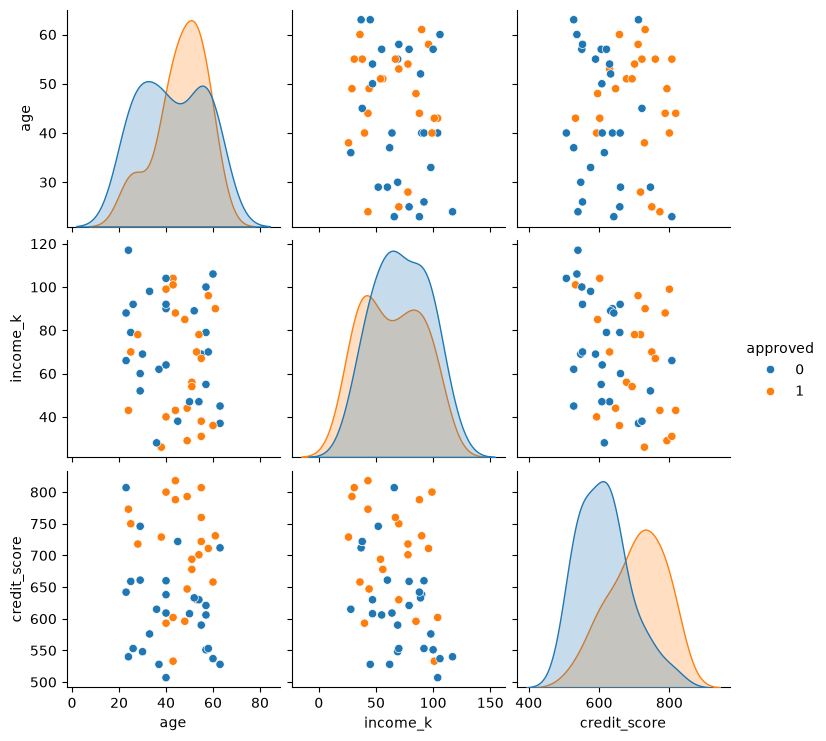

In [43]:
sns.pairplot(
    df,
    hue="approved"
)

plt.show()

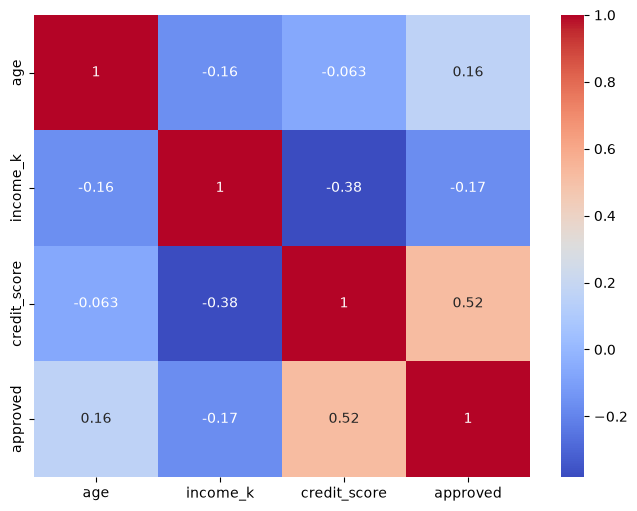

In [44]:
corr = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [45]:
X = df.drop("approved", axis=1)

y = df["approved"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
model = {
    "logistic regression": LogisticRegression(),
    "decision tree": DecisionTreeClassifier(),
    "random forest": RandomForestClassifier(max_depth=5,n_estimators=100),
    "support vector machine": SVC(gamma="scale"),
    "naive bayes": GaussianNB(),
    "k-nearest neighbors": KNeighborsClassifier(),
}
results = []
for name, model in model.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}")
 

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
    })


logistic regression Accuracy: 0.90, Precision: 1.00, Recall: 0.80
decision tree Accuracy: 0.70, Precision: 0.75, Recall: 0.60
random forest Accuracy: 0.70, Precision: 0.75, Recall: 0.60
support vector machine Accuracy: 0.90, Precision: 1.00, Recall: 0.80
naive bayes Accuracy: 0.90, Precision: 1.00, Recall: 0.80
k-nearest neighbors Accuracy: 0.80, Precision: 1.00, Recall: 0.60


In [55]:
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall
0,logistic regression,0.9,1.00,0.8
1,decision tree,0.7,0.75,0.6
2,random forest,0.7,0.75,0.6
3,support vector machine,0.9,1.00,0.8
4,naive bayes,0.9,1.00,0.8
5,k-nearest neighbors,0.8,1.00,0.6


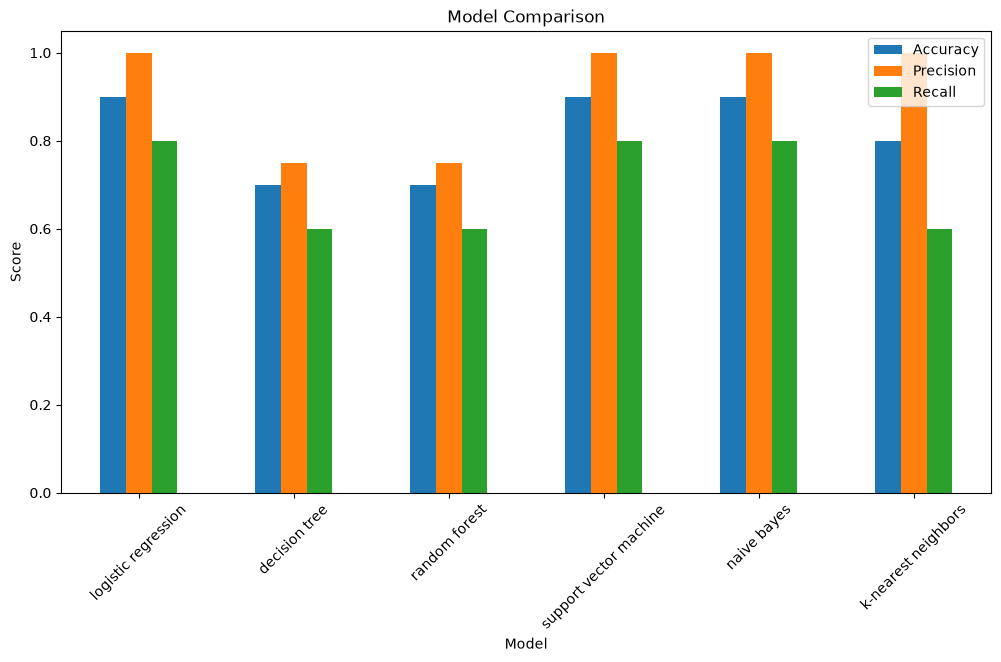

In [51]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Score")
plt.title("Model Comparison")

plt.xticks(rotation=45)
plt.show()

In [60]:
rf=RandomForestClassifier(random_state=0)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(
    X_train,
    y_train
)
print(grid_search.best_params_)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
0.4609523809523809
RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200, random_state=0)


              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10

0.92


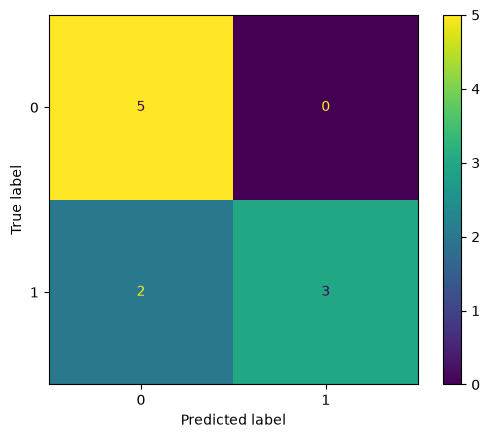

In [61]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred
    )
)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [64]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"classification_report(y_test, y_pred):\n{classification_report(y_test, y_pred)}")

Accuracy: 0.90
Precision: 1.00
Recall: 0.80
classification_report(y_test, y_pred):
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



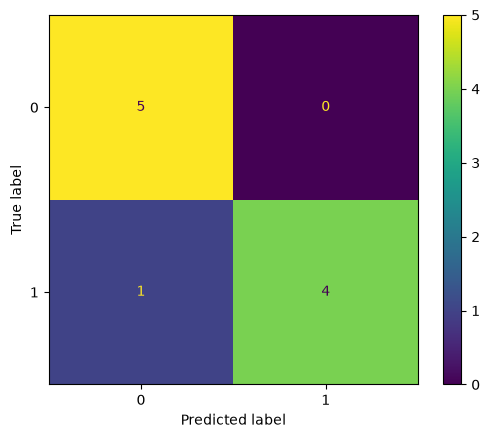

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [66]:
import joblib
joblib.dump(model,'loan_approval_model.pkl')

['loan_approval_model.pkl']